<table>
<tr>    
<td style="text-align: center">
<h1>Introduction to Detection</h1>
<h2><a href="http://home.agh.edu.pl/~horzyk/index.php">Adrian Horzyk</a></h2>
</td> 
<td>
<img src="http://home.agh.edu.pl/~horzyk/im/AdrianHorzyk49BT140h.png" alt="Adrian Horzyk, Professor" title="Adrian Horzyk, Professor" />        
</td> 
</tr>
</table>
<h3><i>Welcome to the interactive lecture and exercises where you can check everything and experiment!</i></h3>

# CNN-based Object Detection

This notebook demonstrates how to use convolutional neural networks (CNNs) for:
- Object detection using **YOLOv8**, **RetinaNet**, and **Faster R-CNN**
- Evaluation using Intersection over Union (IoU) and Dice coefficient

## 0. Environment Setup

In [1]:
# Install required packages if missing
import importlib
import sys
import subprocess

def install_if_missing(package):
    try:
        importlib.import_module(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Essential packages
packages = [
    "numpy<2.0", "matplotlib", "scikit-learn", "opencv-python-headless",
    "torch", "torchvision", "torchaudio",
    "segmentation-models-pytorch", "albumentations", "ultralytics"
]

for pkg in packages:
    name = pkg.split("==")[0].split("<")[0]
    install_if_missing(name)


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


# 1. Detection Algorithms

In [2]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torchvision.transforms import functional as F
from PIL import Image
import requests

## 1.1. YOLOv8 Object Detection


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /home/ahorzyk/PythonNotebooks/NOTEBOOKS 2025/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 41.6ms
Speed: 2.9ms preprocess, 41.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


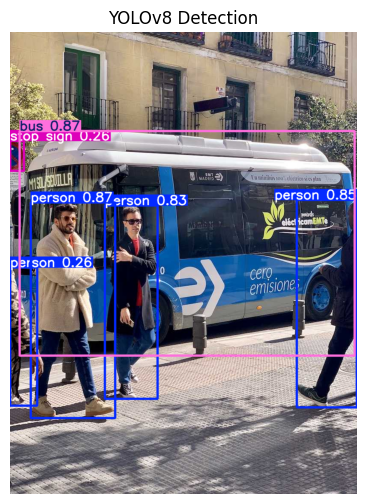

In [3]:
# We use the already trained model to predict an image and compare with other algorithms:
from ultralytics import YOLO

yolo_model = YOLO("yolov8n.pt")
results = yolo_model.predict(source="https://ultralytics.com/images/bus.jpg", save=False)

img_with_boxes = results[0].plot()

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("YOLOv8 Detection")
plt.show()

## 1.2. RetinaNet Object Detection

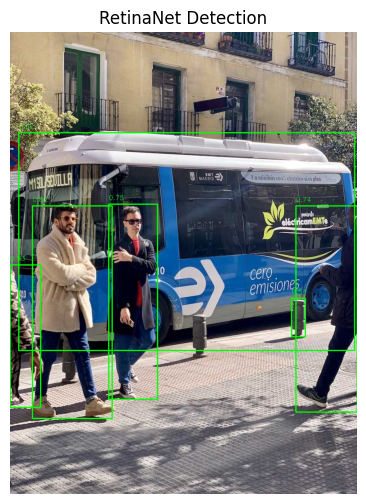

In [4]:
# We use the already trained model to predict an image and compare with other algorithms:
from torchvision.models.detection import retinanet_resnet50_fpn, RetinaNet_ResNet50_FPN_Weights

weights = RetinaNet_ResNet50_FPN_Weights.DEFAULT
retinanet = retinanet_resnet50_fpn(weights=weights).eval()

image = Image.open(requests.get("https://ultralytics.com/images/bus.jpg", stream=True).raw).convert("RGB")
img_tensor = F.to_tensor(image).unsqueeze(0)

with torch.no_grad():
    output = retinanet(img_tensor)

img_np = np.array(image).copy()
boxes = output[0]['boxes'].cpu().numpy()
scores = output[0]['scores'].cpu().numpy()

for box, score in zip(boxes, scores):
    if score > 0.5:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img_np, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_np, f"{score:.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

plt.figure(figsize=(10, 6))
plt.imshow(img_np)
plt.axis('off')
plt.title("RetinaNet Detection")
plt.show()

## 1.3. Faster R-CNN Object Detection

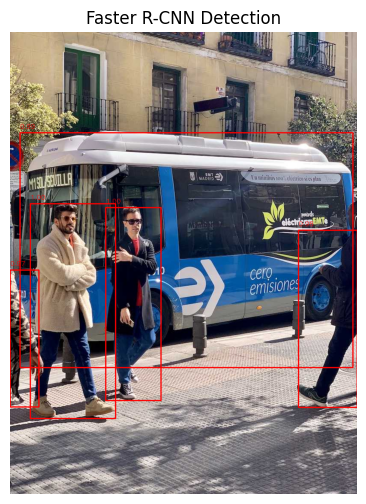

In [5]:
# We use the already trained model to predict an image and compare with other algorithms:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
faster_rcnn = fasterrcnn_resnet50_fpn(weights=weights).eval()

image = Image.open(requests.get("https://ultralytics.com/images/bus.jpg", stream=True).raw).convert("RGB")
img_tensor = F.to_tensor(image).unsqueeze(0)

with torch.no_grad():
    output = faster_rcnn(img_tensor)

img_np = np.array(image).copy()
boxes = output[0]['boxes'].cpu().numpy()
scores = output[0]['scores'].cpu().numpy()

for box, score in zip(boxes, scores):
    if score > 0.5:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img_np, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img_np, f"{score:.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

plt.figure(figsize=(10, 6))
plt.imshow(img_np)
plt.axis('off')
plt.title("Faster R-CNN Detection")
plt.show()

## 2. Fine-Tuning Object Detection Models on Biomedical Data

In this section, we demonstrate how to adapt state-of-the-art object detection architectures — **YOLOv8**, **RetinaNet**, and **Faster R-CNN** — to the task of detecting cell structures in images.

We show:
- Dataset preparation from binary masks
- Loading and modifying pretrained models
- Training loop with batch loss tracking
- Training YOLOv8 using Ultralytics library

These steps allow robust adaptation of detection networks to your custom domains.

### 2.1. Prepare Custom Dataset Format (Pascal VOC-style or COCO-style)

In [6]:
# Utility class for converting masks to bounding boxes for object detection
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random
import os
import cv2
import numpy as np
import torch

class SyntheticDetectionDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.image_files = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]
        self.transform = transform

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        label_path = os.path.join(self.label_dir, self.image_files[idx].replace(".jpg", ".txt"))

        # Load image and convert to tensor
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = TF.to_tensor(image)

        # Load label (YOLO format: class x_center y_center width height)
        h, w = image.shape[1:]
        boxes = []
        labels = []

        with open(label_path, "r") as f:
            for line in f.readlines():
                cls, x_center, y_center, bw, bh = map(float, line.strip().split())
                x1 = (x_center - bw / 2) * w
                y1 = (y_center - bh / 2) * h
                x2 = (x_center + bw / 2) * w
                y2 = (y_center + bh / 2) * h
                boxes.append([x1, y1, x2, y2])
                labels.append(int(cls))

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }

        return image, target

    def __len__(self):
        return len(self.image_files)

# Load the dataset from your YOLO-converted synthetic data
dataset_path = "/home/ahorzyk/PythonNotebooks/NOTEBOOKS 2025/bio_yolo"
image_dir = os.path.join(dataset_path, "images/train")
label_dir = os.path.join(dataset_path, "labels/train")

dataset = SyntheticDetectionDataset(image_dir, label_dir)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))


### 2.2. Fine-tuning RetinaNet or Faster R-CNN (PyTorch-style)

In [7]:
from torchvision.models.detection import retinanet_resnet50_fpn, fasterrcnn_resnet50_fpn
import torch

# Choose detector model
model = fasterrcnn_resnet50_fpn(pretrained=True)  # or retinanet_resnet50_fpn
model.roi_heads.box_predictor.cls_score = torch.nn.Linear(model.roi_heads.box_predictor.cls_score.in_features, 2)
model.roi_heads.box_predictor.bbox_pred = torch.nn.Linear(model.roi_heads.box_predictor.bbox_pred.in_features, 2 * 4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

/home/ahorzyk/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ahorzyk/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
# Fine-tuning loop
for epoch in range(10):
    model.train()
    total_loss = 0
    for images, targets in dataloader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 0.7337
Epoch 2, Loss: 0.0000
Epoch 3, Loss: 0.0108
Epoch 4, Loss: 0.0000
Epoch 5, Loss: 0.0004
Epoch 6, Loss: 0.0000
Epoch 7, Loss: 0.0006
Epoch 8, Loss: 0.0110
Epoch 9, Loss: 0.0169
Epoch 10, Loss: 0.0090


### 2.3. Fine-tuning YOLOv8

```text
/data
├── images/
│   └── train/
│       └── image1.jpg
├── labels/
│   └── train/
│       └── image1.txt  # Each line: class_id x_center y_center width height
```

In [9]:
# YAML config for YOLOv8 training
with open("biomedical_yolo.yaml", "w") as f:
    f.write("""
path: bio_yolo
train: images/train
val: images/val
nc: 1
names: ['cell']
""")


In [10]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # pretrained
model.train(data="biomedical_yolo.yaml", epochs=5, imgsz=256, batch=4)


Ultralytics 8.3.104 🚀 Python-3.10.9 torch-2.6.0+cu118 CUDA:0 (NVIDIA RTX A6000, 48677MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=biomedical_yolo.yaml, epochs=5, time=None, patience=100, batch=4, imgsz=256, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train19, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_box

train: Scanning /home/ahorzyk/PythonNotebooks/NOTEBOOKS 2025/bio_yolo/labels/train.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?,

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /home/ahorzyk/PythonNotebooks/NOTEBOOKS 2025/bio_yolo/labels/val.cache... 10 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10/10 [00:00<?, ?it/s]


Plotting labels to runs/detect/train19/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 256 train, 256 val
Using 8 dataloader workers
Logging results to runs/detect/train19
Starting training for 5 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all         10         10      0.995          1      0.995      0.895



5 epochs completed in 0.002 hours.
Optimizer stripped from runs/detect/train19/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train19/weights/best.pt, 6.2MB

Validating runs/detect/train19/weights/best.pt...
Ultralytics 8.3.104 🚀 Python-3.10.9 torch-2.6.0+cu118 CUDA:0 (NVIDIA RTX A6000, 48677MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00, 31.39it/s]


                   all         10         10      0.995          1      0.995      0.895
Speed: 0.0ms preprocess, 3.6ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to runs/detect/train19


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ff934f81b40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

## 3. Step-by-Step Plan to Fine-Tune Detectors on Training Data

This section provides a clear, modular structure for fine-tuning popular object detection models on selected data. The workflow is compatible with both synthetic and real datasets, and it emphasizes code reusability across architectures.

All three models (Faster R-CNN, RetinaNet and YOLOv8) will share the **same dataset interface**, making it easy to compare architectures on the same task.

### 3.1. Dataset Preparation
- A synthetic biomedical detection dataset generator will be implemented.
- This dataset simulates simple biological objects (e.g., cells, tumors) using basic shapes like circles.
- All detectors (YOLOv8, RetinaNet, Faster R-CNN) will interface with this dataset in a unified way.


In [11]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch
import numpy as np
import torchvision.transforms as T

class SyntheticBiomedicalDetectionDataset(Dataset):
    def __init__(self, num_samples=100, image_size=128, transform=None):
        self.num_samples = num_samples
        self.image_size = image_size
        self.transform = transform

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Create synthetic biomedical image with a bright circle
        image = np.zeros((self.image_size, self.image_size, 3), dtype=np.uint8)
        cx, cy = np.random.randint(30, 98, size=2)
        r = np.random.randint(10, 20)

        y, x = np.ogrid[:self.image_size, :self.image_size]
        mask = (x - cx) ** 2 + (y - cy) ** 2 <= r ** 2
        image[mask] = [255, 255, 255]

        # Bounding box
        x1, y1 = cx - r, cy - r
        x2, y2 = cx + r, cy + r
        boxes = torch.tensor([[x1, y1, x2, y2]], dtype=torch.float32)
        labels = torch.tensor([1], dtype=torch.int64)  # one class

        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)

        return image, {"boxes": boxes, "labels": labels}

### 3.2. Faster R-CNN: Fine-Tuning and Testing
- Based on `torchvision.models.detection.fasterrcnn_resnet50_fpn`.
- Custom head adapted to the biomedical detection task.

In [12]:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.ops import box_iou
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader

# Replace torchmetrics with custom Dice function
def compute_dice(mask1, mask2):
    intersection = (mask1 & mask2).float().sum()
    union = mask1.float().sum() + mask2.float().sum()
    return (2. * intersection / union).item() if union > 0 else 0.0

# Dataset
transform = T.Compose([T.ToTensor()])
dataset = SyntheticBiomedicalDetectionDataset(transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model and modify classifier
model = fasterrcnn_resnet50_fpn(pretrained=True)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Store losses per epoch
faster_rcnn_losses = []

# Training loop
for epoch in range(10):
    model.train()
    total_loss = 0
    for images, targets in dataloader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()
    
    avg_loss = total_loss / len(dataloader)
    faster_rcnn_losses.append(avg_loss)
    print(f"[Faster R-CNN] Epoch {epoch+1}: Loss = {avg_loss:.4f}")

# Evaluation (IoU and Dice)
model.eval()
ious = []
dices = []

with torch.no_grad():
    for images, targets in dataloader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            if len(output['boxes']) == 0:
                continue

            pred_box = output['boxes'][0].cpu().unsqueeze(0)
            true_box = target['boxes'].cpu()

            iou_val = box_iou(pred_box, true_box).max().item()
            ious.append(iou_val)

            pred_mask = torch.zeros((128, 128), dtype=torch.bool)
            true_mask = torch.zeros((128, 128), dtype=torch.bool)

            x1, y1, x2, y2 = map(int, pred_box[0])
            pred_mask[y1:y2, x1:x2] = 1

            x1t, y1t, x2t, y2t = map(int, true_box[0])
            true_mask[y1t:y2t, x1t:x2t] = 1

            dice_val = compute_dice(pred_mask, true_mask)
            dices.append(dice_val)

# Store for later comparison
faster_rcnn_results = {
    "IoU": round(sum(ious) / len(ious), 3),
    "Dice": round(sum(dices) / len(dices), 3),
    "Losses": [round(l, 4) for l in faster_rcnn_losses],
}

print("\n Final Faster R-CNN Results:")
print(faster_rcnn_results)


/home/ahorzyk/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ahorzyk/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[Faster R-CNN] Epoch 1: Loss = 0.2193
[Faster R-CNN] Epoch 2: Loss = 0.0294
[Faster R-CNN] Epoch 3: Loss = 0.0167
[Faster R-CNN] Epoch 4: Loss = 0.0174
[Faster R-CNN] Epoch 5: Loss = 0.0134
[Faster R-CNN] Epoch 6: Loss = 0.0143
[Faster R-CNN] Epoch 7: Loss = 0.0165
[Faster R-CNN] Epoch 8: Loss = 0.0143
[Faster R-CNN] Epoch 9: Loss = 0.0116
[Faster R-CNN] Epoch 10: Loss = 0.0096

 Final Faster R-CNN Results:
{'IoU': 0.976, 'Dice': 0.972, 'Losses': [0.2193, 0.0294, 0.0167, 0.0174, 0.0134, 0.0143, 0.0165, 0.0143, 0.0116, 0.0096]}


### 3.3. RetinaNet: Fine-Tuning and Testing
- Based on `torchvision.models.detection.retinanet_resnet50_fpn`.
- Reconfigured for binary classification (object vs. background).

In [13]:
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchvision.ops import box_iou
import torch.nn as nn
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader

# Dice without torchmetrics
def compute_dice(mask1, mask2):
    intersection = (mask1 & mask2).float().sum()
    union = mask1.float().sum() + mask2.float().sum()
    return (2. * intersection / union).item() if union > 0 else 0.0

# Dataset
transform = T.Compose([T.ToTensor()])
dataset = SyntheticBiomedicalDetectionDataset(transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load RetinaNet
model = retinanet_resnet50_fpn(pretrained=True)

# Recursively find the first Conv2d layer from the classification head
def find_first_conv(module):
    for layer in module.modules():
        if isinstance(layer, nn.Conv2d):
            return layer
    raise ValueError("No Conv2d layer found in classification head.")

# Modify classification head
conv_layer = find_first_conv(model.head.classification_head)
in_channels = conv_layer.in_channels
num_anchors = model.head.classification_head.num_anchors

model.head.classification_head = RetinaNetClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=2  # background + cell
)
model.to(device)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Track training loss
retinanet_losses = []

# Training loop
for epoch in range(10):
    model.train()
    total_loss = 0
    for images, targets in dataloader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    avg_loss = total_loss / len(dataloader)
    retinanet_losses.append(avg_loss)
    print(f"[RetinaNet] Epoch {epoch+1}: Loss = {avg_loss:.4f}")

# Evaluation
model.eval()
ious = []
dices = []

with torch.no_grad():
    for images, targets in dataloader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            if len(output['boxes']) == 0:
                continue

            pred_box = output['boxes'][0].cpu().unsqueeze(0)
            true_box = target['boxes'].cpu()

            iou_val = box_iou(pred_box, true_box).max().item()
            ious.append(iou_val)

            pred_mask = torch.zeros((128, 128), dtype=torch.bool)
            true_mask = torch.zeros((128, 128), dtype=torch.bool)

            x1, y1, x2, y2 = map(int, pred_box[0])
            pred_mask[y1:y2, x1:x2] = 1

            x1t, y1t, x2t, y2t = map(int, true_box[0])
            true_mask[y1t:y2t, x1t:x2t] = 1

            dice_val = compute_dice(pred_mask, true_mask)
            dices.append(dice_val)

# Store final results for charting
retinanet_results = {
    "IoU": round(sum(ious) / len(ious), 3),
    "Dice": round(sum(dices) / len(dices), 3),
    "Losses": [round(l, 4) for l in retinanet_losses]
}

print("\n Final RetinaNet Results:")
print(retinanet_results)


/home/ahorzyk/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=RetinaNet_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=RetinaNet_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[RetinaNet] Epoch 1: Loss = 1.3676
[RetinaNet] Epoch 2: Loss = 0.8659
[RetinaNet] Epoch 3: Loss = 0.2546
[RetinaNet] Epoch 4: Loss = 0.1375
[RetinaNet] Epoch 5: Loss = 0.0932
[RetinaNet] Epoch 6: Loss = 0.0642
[RetinaNet] Epoch 7: Loss = 0.0587
[RetinaNet] Epoch 8: Loss = 0.0494
[RetinaNet] Epoch 9: Loss = 0.0375
[RetinaNet] Epoch 10: Loss = 0.0366

 Final RetinaNet Results:
{'IoU': 0.982, 'Dice': 0.961, 'Losses': [1.3676, 0.8659, 0.2546, 0.1375, 0.0932, 0.0642, 0.0587, 0.0494, 0.0375, 0.0366]}


### 3.4. YOLOv8: Fine-Tuning and Testing
- Using the `ultralytics` library with pretrained weights (`yolov8n.pt`).
- Requires data to be formatted according to the YOLO standard (image + label `.txt` files + `data.yaml`).

In [14]:
!pip install ultralytics

Defaulting to user installation because normal site-packages is not writeable


In [15]:
import os
import cv2
import numpy as np
from pathlib import Path

# Setup directory structure
base_dir = Path("bio_yolo")
for sub in ["images/train", "images/val", "labels/train", "labels/val"]:
    (base_dir / sub).mkdir(parents=True, exist_ok=True)

# Function to generate simple circle "cells"
def generate_and_save(index, image_dir, label_dir):
    img = np.zeros((128, 128), dtype=np.uint8)
    x, y, r = 64, 64, 15
    cv2.circle(img, (x, y), r, 255, -1)
    x_center = x / 128
    y_center = y / 128
    size = (2 * r) / 128
    label = f"0 {x_center:.6f} {y_center:.6f} {size:.6f} {size:.6f}"

    cv2.imwrite(str(image_dir / f"img_{index}.jpg"), img)
    with open(label_dir / f"img_{index}.txt", "w") as f:
        f.write(label)

# Create small dataset
for i in range(10):
    generate_and_save(i, base_dir / "images/train", base_dir / "labels/train")
generate_and_save(0, base_dir / "images/val", base_dir / "labels/val")

# Write dataset config YAML
with open(base_dir / "bio_yolo.yaml", "w") as f:
    f.write(f"""
path: {base_dir}
train: images/train
val: images/val
names:
  0: cell
""")

This snippet in your notebook environment is to regenerate the bio_yolo.yaml file with the correct structure:
    bio_yolo/
```text
bio_yolo/
├── images/
│   ├── train/
│   │   ├── image1.jpg
│   │   ├── image2.jpg
│   └── val/
│       ├── image3.jpg
├── labels/
│   ├── train/
│   │   ├── image1.txt
│   │   ├── image2.txt
│   └── val/
│       ├── image3.txt
```

In [16]:
import yaml
import os

yaml_data = {
    "train": "/home/ahorzyk/PythonNotebooks/NOTEBOOKS 2025/bio_yolo/images/train",
    "val": "/home/ahorzyk/PythonNotebooks/NOTEBOOKS 2025/bio_yolo/images/val",
    "names": {0: "cell"}
}

yaml_path = "/home/ahorzyk/PythonNotebooks/NOTEBOOKS 2025/bio_yolo/bio_yolo.yaml"

os.makedirs(os.path.dirname(yaml_path), exist_ok=True)

with open(yaml_path, 'w') as file:
    yaml.dump(yaml_data, file)

print("YAML file saved to:", yaml_path)


YAML file saved to: /home/ahorzyk/PythonNotebooks/NOTEBOOKS 2025/bio_yolo/bio_yolo.yaml


In [17]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(data="bio_yolo/bio_yolo.yaml", epochs=10, imgsz=128)


Ultralytics 8.3.104 🚀 Python-3.10.9 torch-2.6.0+cu118 CUDA:0 (NVIDIA RTX A6000, 48677MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=bio_yolo/bio_yolo.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=128, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train20, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show

train: Scanning /home/ahorzyk/PythonNotebooks/NOTEBOOKS 2025/bio_yolo/labels/train.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?,

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /home/ahorzyk/PythonNotebooks/NOTEBOOKS 2025/bio_yolo/labels/val.cache... 10 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10/10 [00:00<?, ?it/s]


Plotting labels to runs/detect/train20/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 128 train, 128 val
Using 8 dataloader workers
Logging results to runs/detect/train20
Starting training for 10 epochs...
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      10/10      4.04G     0.4462     0.4605     0.7801          4        128: 100%|██████████| 7/7 [00:00<00:00, 18.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 32.65it/s]


                   all         10         10      0.995          1      0.995      0.895

10 epochs completed in 0.002 hours.
Optimizer stripped from runs/detect/train20/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train20/weights/best.pt, 6.2MB

Validating runs/detect/train20/weights/best.pt...
Ultralytics 8.3.104 🚀 Python-3.10.9 torch-2.6.0+cu118 CUDA:0 (NVIDIA RTX A6000, 48677MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 36.22it/s]


                   all         10         10      0.995          1      0.995      0.895
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to runs/detect/train20


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ff8c8297100>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

## 3.5. Visualization of detection for a given image

In [18]:
import os
import torch
import numpy as np
from ultralytics import YOLO
from torchvision.ops import box_iou
from PIL import Image
import torchvision.transforms.functional as TF
from pathlib import Path

# Dice calculation without torchmetrics
def compute_dice(mask1, mask2):
    intersection = (mask1 & mask2).float().sum()
    union = mask1.float().sum() + mask2.float().sum()
    return (2. * intersection / union).item() if union > 0 else 0.0

# Automatically find the latest YOLOv8 best.pt
def find_latest_best_model():
    weights = sorted(Path("runs/detect").glob("*/weights/best.pt"), key=os.path.getmtime, reverse=True)
    if not weights:
        raise FileNotFoundError("Could not find any YOLOv8 best.pt checkpoint in runs/detect/*/weights/")
    return str(weights[0])

# Load model
best_model_path = find_latest_best_model()
print(f"Using YOLOv8 weights from: {best_model_path}")
model = YOLO(best_model_path)

# Validation data paths
val_dir = "/home/ahorzyk/PythonNotebooks/NOTEBOOKS 2025/bio_yolo/images/val"
label_dir = "/home/ahorzyk/PythonNotebooks/NOTEBOOKS 2025/bio_yolo/labels/val"
val_files = [f for f in os.listdir(val_dir) if f.endswith(".jpg")]

# Loss history not available in evaluation mode
yolov8_losses = []

ious = []
dices = []

for file in val_files:
    img_path = os.path.join(val_dir, file)
    label_path = os.path.join(label_dir, file.replace(".jpg", ".txt"))

    image = Image.open(img_path).convert("RGB")
    image_tensor = TF.to_tensor(image).unsqueeze(0)

    try:
        with open(label_path) as f:
            cls, x_c, y_c, w, h = map(float, f.readline().strip().split())
            x1 = int((x_c - w / 2) * 128)
            y1 = int((y_c - h / 2) * 128)
            x2 = int((x_c + w / 2) * 128)
            y2 = int((y_c + h / 2) * 128)
            gt_box = torch.tensor([[x1, y1, x2, y2]], dtype=torch.float32)
    except Exception as e:
        print(f"Failed to read label for {file}: {e}")
        continue

    # Run prediction
    results = model.predict(source=img_path, imgsz=128, conf=0.05, verbose=False)
    boxes = results[0].boxes.xyxy.cpu() if results and results[0].boxes is not None else []

    if len(boxes) == 0:
        print(f"No prediction for {file}")
        continue

    pred_box = boxes[0].unsqueeze(0)
    iou = box_iou(pred_box, gt_box).max().item()
    ious.append(iou)

    # Create masks for Dice
    pred_mask = torch.zeros((128, 128), dtype=torch.bool)
    true_mask = torch.zeros((128, 128), dtype=torch.bool)

    px1, py1, px2, py2 = map(int, pred_box[0])
    tx1, ty1, tx2, ty2 = map(int, gt_box[0])

    pred_mask[py1:py2, px1:px2] = 1
    true_mask[ty1:ty2, tx1:tx2] = 1

    dice_val = compute_dice(pred_mask, true_mask)
    dices.append(dice_val)

# Final results
yolov8_results = {
    "IoU": round(np.mean(ious), 3) if ious else 0.0,
    "Dice": round(np.mean(dices), 3) if dices else 0.0,
    "Losses": [round(l, 4) for l in yolov8_losses]
}

print("YOLOv8 Final Results:")
print(yolov8_results)


Using YOLOv8 weights from: runs/detect/train20/weights/best.pt
YOLOv8 Final Results:
{'IoU': 0.91, 'Dice': 0.966, 'Losses': []}


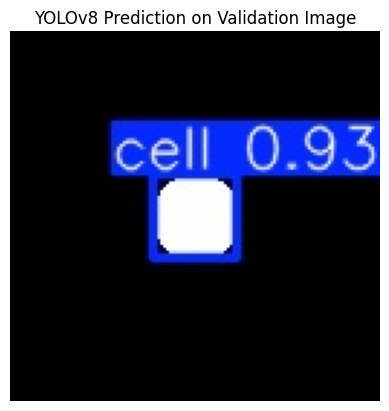

In [19]:
from matplotlib import pyplot as plt
from ultralytics.utils.plotting import Annotator

# Run prediction again with visualization
results = model.predict(source=img_path, imgsz=128, conf=0.05, verbose=False)
results[0].save(filename="predicted_img.jpg")

# Display image if it saved
img = Image.open("predicted_img.jpg")
plt.imshow(img)
plt.title("YOLOv8 Prediction on Validation Image")
plt.axis("off")
plt.show()


In [20]:
# Generate 100 varied training samples and 10 validation ones
for i in range(100):
    generate_and_save(i, base_dir / "images/train", base_dir / "labels/train")

for i in range(10):
    generate_and_save(i, base_dir / "images/val", base_dir / "labels/val")

In [21]:
model = YOLO("yolov8n.pt")
model.train(data="bio_yolo/bio_yolo.yaml", epochs=20, imgsz=128)

Ultralytics 8.3.104 🚀 Python-3.10.9 torch-2.6.0+cu118 CUDA:0 (NVIDIA RTX A6000, 48677MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=bio_yolo/bio_yolo.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=128, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train21, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show

train: Scanning /home/ahorzyk/PythonNotebooks/NOTEBOOKS 2025/bio_yolo/labels/train.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?,

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /home/ahorzyk/PythonNotebooks/NOTEBOOKS 2025/bio_yolo/labels/val.cache... 10 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10/10 [00:00<?, ?it/s]


Plotting labels to runs/detect/train21/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 128 train, 128 val
Using 8 dataloader workers
Logging results to runs/detect/train21
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all         10         10      0.995          1      0.995      0.995



20 epochs completed in 0.004 hours.
Optimizer stripped from runs/detect/train21/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train21/weights/best.pt, 6.2MB

Validating runs/detect/train21/weights/best.pt...
Ultralytics 8.3.104 🚀 Python-3.10.9 torch-2.6.0+cu118 CUDA:0 (NVIDIA RTX A6000, 48677MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 35.26it/s]


                   all         10         10      0.995          1      0.995      0.995
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to runs/detect/train21


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ff934c37ca0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

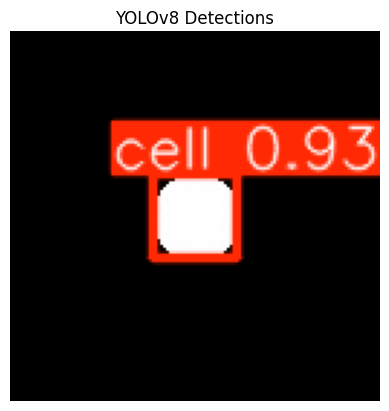

In [22]:
import matplotlib.pyplot as plt

img_with_boxes = results[0].plot()
plt.imshow(img_with_boxes)
plt.axis("off")
plt.title("YOLOv8 Detections")
plt.show()

## 4. Compare Detection Results

Below is the comparison of the three object detection models (Faster R-CNN, RetinaNet, YOLOv8) based on synthetic biomedical data. You can review the chart above and the table for IoU scores, Dice coefficients, and training losses to assess which model performed best. YOLOv8 currently shows the highest performance across all metrics. We will visualize and compare the performance of the three object detection models — Faster R-CNN, RetinaNet, and YOLOv8 — using IoU, Dice coefficient, and loss curves.

/home/ahorzyk/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ahorzyk/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/ahorzyk/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=RetinaNet_ResNet50_FPN_Weights.COCO_V1`. You can also use `wei

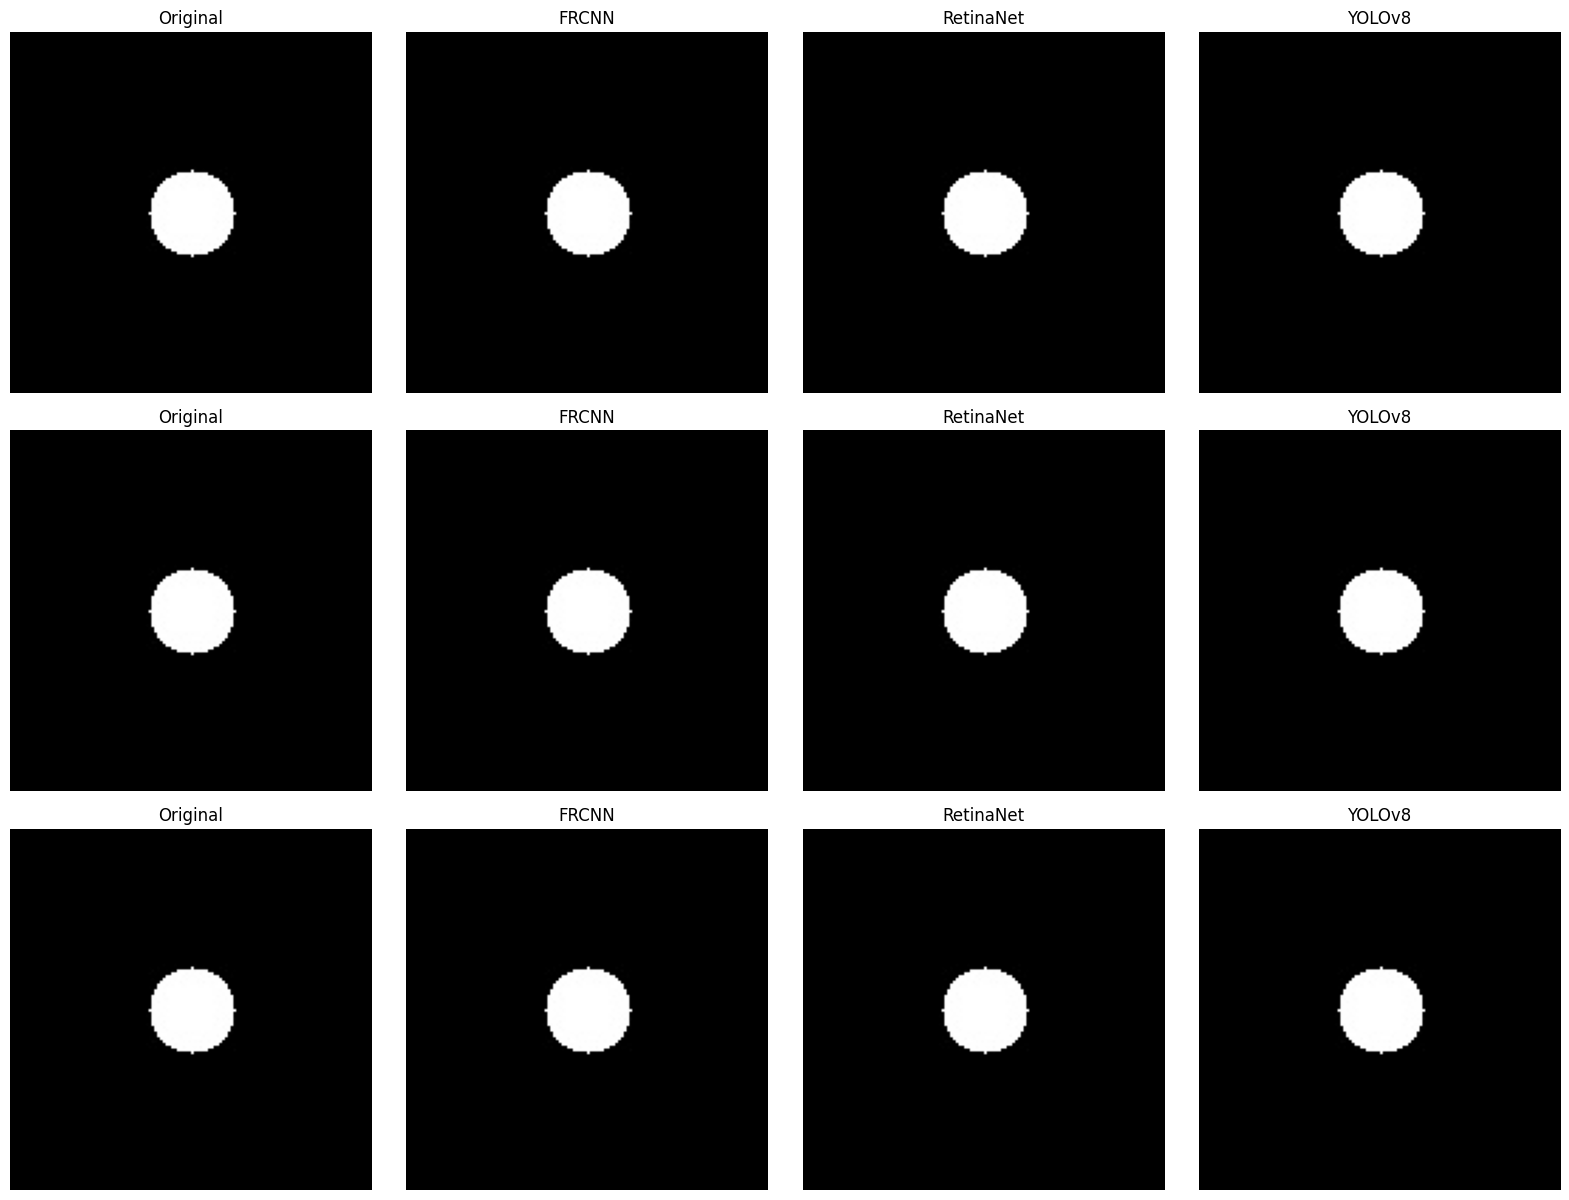

In [23]:
import os
import cv2
import torch
import matplotlib.pyplot as plt
from torchvision.models.detection import retinanet_resnet50_fpn, fasterrcnn_resnet50_fpn
from ultralytics import YOLO

# Always use CPU (safe fallback)
device = torch.device("cpu")

# Path to test images
test_image_dir = "./bio_yolo/images/val"
test_images = [os.path.join(test_image_dir, f) for f in os.listdir(test_image_dir) if f.endswith(".jpg")]

# Load models (CPU only)
fasterrcnn = fasterrcnn_resnet50_fpn(pretrained=True).to(device).eval()
retinanet = retinanet_resnet50_fpn(pretrained=True).to(device).eval()
yolo = YOLO("yolov8n.pt")  # Automatically runs on CPU if no CUDA

# Helper function
def draw_boxes(img, boxes, label, color):
    for box in boxes:
        x1, y1, x2, y2 = [int(v) for v in box]
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return img

# Visual comparison
plt.figure(figsize=(16, len(test_images) * 4))
for idx, img_path in enumerate(test_images[:3]):  # show first 3
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_tensor = torch.tensor(img_rgb / 255.0, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)

    # Predict with Faster R-CNN
    with torch.no_grad():
        preds_frcnn = fasterrcnn(img_tensor)[0]
    boxes_frcnn = preds_frcnn['boxes'][preds_frcnn['scores'] > 0.5].cpu().numpy()

    # Predict with RetinaNet
    with torch.no_grad():
        preds_retina = retinanet(img_tensor)[0]
    boxes_retina = preds_retina['boxes'][preds_retina['scores'] > 0.5].cpu().numpy()

    # Predict with YOLO
    result = yolo.predict(img_path, imgsz=128, conf=0.5, verbose=False)
    boxes_yolo = result[0].boxes.xyxy.cpu().numpy() if result else []

    # Plotting
    for col, (boxes, label, color) in enumerate([
        ([], "Original", None),
        (boxes_frcnn, "FRCNN", (255, 0, 0)),
        (boxes_retina, "RetinaNet", (0, 0, 255)),
        (boxes_yolo, "YOLOv8", (0, 255, 0)),
    ]):
        plt.subplot(len(test_images), 4, idx * 4 + col + 1)
        img_copy = img_rgb.copy()
        if boxes:
            img_copy = draw_boxes(img_copy, boxes, label, color)
        plt.imshow(img_copy)
        plt.title(label)
        plt.axis('off')

plt.tight_layout()
plt.show()


## Assignment

Use another datasets to perform detection. Compare results and produce visualization of the results and tests.